In [3]:
import pandas as pd

# Read the dataset to the python environment

df=pd.read_csv('/content/Wholesale customers data.csv')
print(data.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [4]:
# Dropping categorical columns to cluster based on spending behavior
X=df.drop(['Channel','Region'],axis=1)

In [6]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [17]:
# Using K-Means clustering and finding the optimal clusters
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled,kmeans.labels_))

In [18]:
sil_scores

[np.float64(0.3998278091730005),
 np.float64(0.4582633767207058),
 np.float64(0.34939129340421093),
 np.float64(0.36890127429678043),
 np.float64(0.2762464573058837),
 np.float64(0.276678268663421),
 np.float64(0.32366546538940916),
 np.float64(0.29453704649783113),
 np.float64(0.22876866444760022)]

In [19]:
wcss

[2266.9552665832457,
 1644.0598512347563,
 1326.6746082135523,
 1070.2551995135614,
 989.3326418885056,
 856.7070228388113,
 791.8280762163158,
 710.1943394067521,
 668.22250548469]

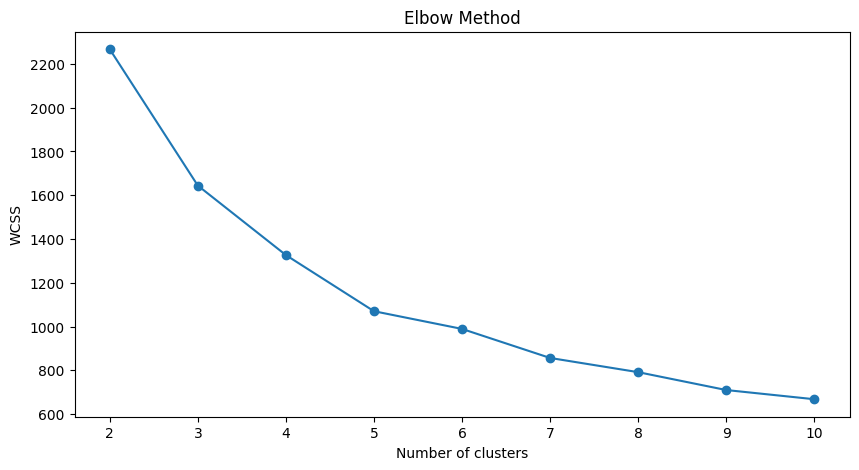

In [15]:
# Optimal number of clusters using Elbow method
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show() # The optimal number of clusters are 5.

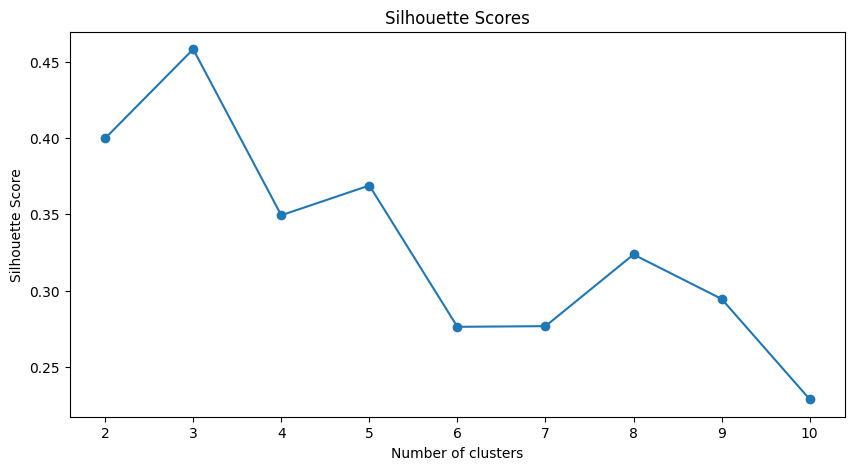

In [22]:
plt.figure(figsize=(10,5))
plt.plot(range(2,11),sil_scores,marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [16]:
# Creating K-Means with the optimal number of clusters (i.e, 5)
kmeans_opt=KMeans(n_clusters=5,init='k-means++',random_state=42)
kmeans_labels=kmeans_opt.fit_predict(X_scaled)

In [23]:
# Hierarchical Clustering and Dendrogram
hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
hc_labels=hc.fit_predict(X_scaled)

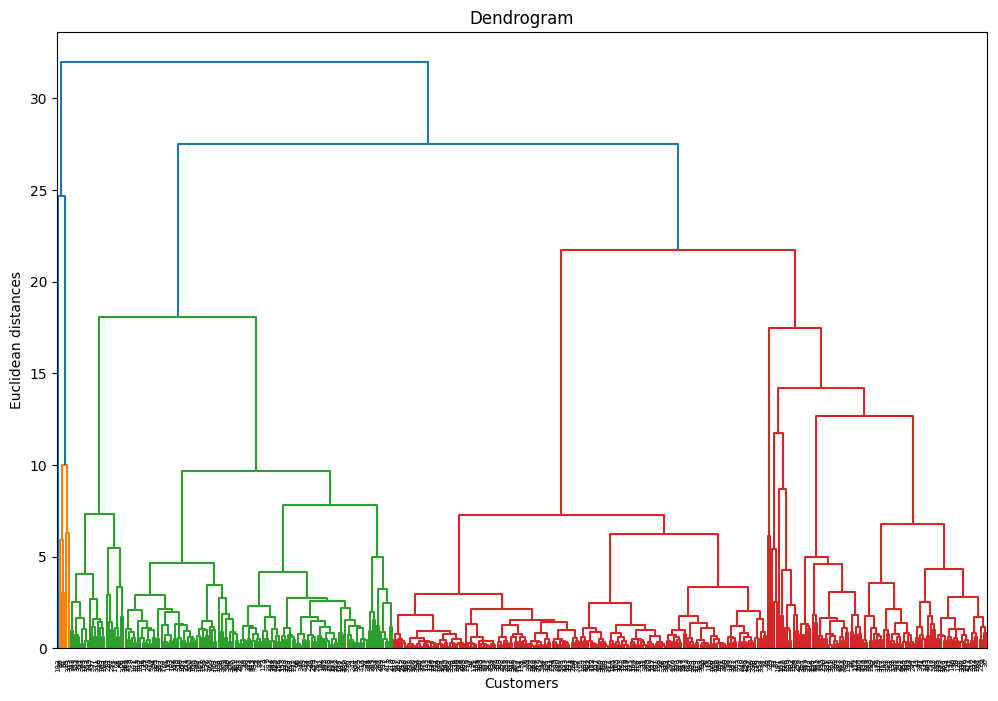

In [26]:
# Graph for hierarchical clustering
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12,8))
dendrogram=sch.dendrogram(sch.linkage(X_scaled,method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [27]:
# DBSCAN Clustering
dbscan=DBSCAN(eps=1.5,min_samples=5)
dbscan_labels=dbscan.fit_predict(X_scaled)
n_clusters_dbscan=len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)

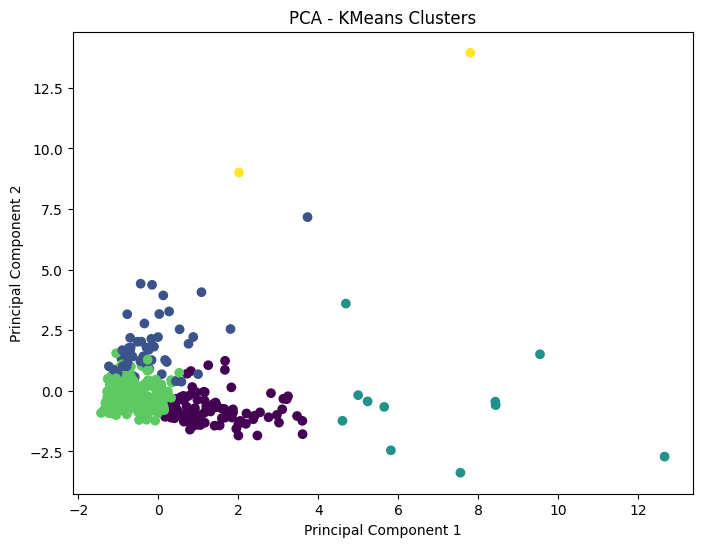

In [29]:
# PCA for Dimensionality Reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0],X_pca[:,1],c=kmeans_labels,cmap='viridis')
plt.title('PCA - KMeans Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [30]:
print("Sil_scores:", sil_scores)
print("DBSCAN Clusters Found:",n_clusters_dbscan)
print("PCA Explained Variance:",pca.explained_variance_ratio_)

Sil_scores: [np.float64(0.3998278091730005), np.float64(0.4582633767207058), np.float64(0.34939129340421093), np.float64(0.36890127429678043), np.float64(0.2762464573058837), np.float64(0.276678268663421), np.float64(0.32366546538940916), np.float64(0.29453704649783113), np.float64(0.22876866444760022)]
DBSCAN Clusters Found: 1
PCA Explained Variance: [0.44082893 0.283764  ]
